# Sea Surface Temperature comparison between MOM6-NEP10k and observational data (OISST) in CCIEA domain
Author: Brooke Hawkins

For details and code to query the MOM6-NEP10k data with Earthmover, see notebook `sst-anomaly.ipynb`. This notebook compares the results.

## Set up

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

config = {
    "mom6_raw_path": "mom6/mom6_monthly_sst_raw.nc",
    "mom6_regrid_path": "mom6/mom6_monthly_sst.nc",
    "oisst_path": "oisst/TS_monthly.nc",
    "mom6_var": "tos",
    "oisst_var": "sst",
    "spatial_bounds": {"lat": [32, 48], "lon": [-128, -116.8]},
    "lon_offset": 360,
    "time_bounds": {"start": None, "end": None},
}


## Load data

In [2]:
# load datasets
mom6_regrid_data = xr.open_dataset(config["mom6_regrid_path"])
mom6_raw_data = xr.open_dataset(config["mom6_raw_path"])
oisst_data = xr.open_dataset(config["oisst_path"])


The MOM6 files contain duplicate time steps for January through June 2025. Each duplicated pair contains identical values, so the first occurrence is retained before comparing either model product with OISST.

In [3]:
# remove duplicate time steps from MOM6
mom6_regrid_data = mom6_regrid_data.drop_duplicates(dim="time", keep="first")
mom6_raw_data = mom6_raw_data.drop_duplicates(dim="time", keep="first")


## Define spatial and temporal extents

The default time bounds are the overlapping dates between MOM6 (raw or regrid) and OISST. In this case, MOM6-NEP10k hindcast has a shorter available time frame than OISST.

In [4]:
# define spatial extent for California Current
lat_bounds = config["spatial_bounds"]["lat"]
lon_bounds = [lon + config["lon_offset"] for lon in config["spatial_bounds"]["lon"]]

# use the shared model period unless explicit bounds are provided
model_time_start = max(
    mom6_regrid_data.time.to_index().min(),
    mom6_raw_data.time.to_index().min(),
    oisst_data.time.to_index().min(),
)
model_time_end = min(
    mom6_regrid_data.time.to_index().max(),
    mom6_raw_data.time.to_index().max(),
    oisst_data.time.to_index().max(),
)
time_bgn = (
    config["time_bounds"]["start"]
    if config["time_bounds"]["start"] is not None
    else model_time_start
)
time_end = (
    config["time_bounds"]["end"]
    if config["time_bounds"]["end"] is not None
    else model_time_end
)

print(f"Date range is {time_bgn} to {time_end}")


Date range is 1993-01-01 00:00:00 to 2025-06-01 00:00:00


In [5]:
# subset MOM6 regrid
mom6_regrid_subset = mom6_regrid_data.sel(
    lat_vec=slice(lat_bounds[0], lat_bounds[1]),
    lon_vec=slice(lon_bounds[0], lon_bounds[1]),
    time=slice(time_bgn, time_end),
)
# subset OISST
oisst_subset = oisst_data.sel(
    lat_vec=slice(lat_bounds[0], lat_bounds[1]),
    lon_vec=slice(lon_bounds[0], lon_bounds[1]),
    time=slice(time_bgn, time_end),
)
# subset MOM6 raw
mom6_raw_time_subset = mom6_raw_data.sel(time=slice(time_bgn, time_end))
spatial_mask = (
    (mom6_raw_time_subset["geolon"] >= lon_bounds[0])
    & (mom6_raw_time_subset["geolon"] <= lon_bounds[1])
    & (mom6_raw_time_subset["geolat"] >= lat_bounds[0])
    & (mom6_raw_time_subset["geolat"] <= lat_bounds[1])
)
mom6_raw_subset = (
    mom6_raw_time_subset.where(spatial_mask)
    .dropna(dim="ih", how="all")
    .dropna(dim="jh", how="all")
)


In [6]:
# check grid sizes
print("MOM6 (regrid) dimensions:", mom6_regrid_subset.sizes)
print("MOM6 (raw) dimensions:", mom6_raw_subset.sizes)
print("OISST dimensions:", oisst_subset.sizes)


MOM6 (regrid) dimensions: Frozen({'time': 390, 'lat_vec': 187, 'lon_vec': 39})
MOM6 (raw) dimensions: Frozen({'time': 390, 'jh': 200, 'ih': 107})
OISST dimensions: Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})


## Check grid resolutions and interpolate

In [7]:
def check_grid_resolution(dataset):
    """
    Analyzes the spatial resolution of a dataset's grid to determine if it is
    regular (uniform spacing), nearly regular (close to uniform spacing, some
    rounding error), or irregular.

    Args:
        dataset: An object (e.g., xarray Dataset) containing 'lat_vec' and 'lon_vec'
                 coordinate arrays that can be converted to pandas Series.
    """
    # check step size between adjacent latitude points to check for uniform spacing
    lat_series = dataset.lat_vec.to_series()
    lat_series_diff = lat_series.diff()
    lat_diff_min = lat_series_diff.min(skipna=True)
    lat_diff_max = lat_series_diff.max(skipna=True)

    # check step size between adjacent longitude points to check for uniform spacing
    lon_series = dataset.lon_vec.to_series()
    lon_series_diff = lon_series.diff()
    lon_diff_min = lon_series_diff.min(skipna=True)
    lon_diff_max = lon_series_diff.max(skipna=True)

    # classify grid resolution based on variance in step sizes
    if lat_diff_min == lat_diff_max and lon_diff_min == lon_diff_max:
        print(
            f"Perfectly regular grid resolution of {lat_diff_min} latitudinal degrees by {lon_diff_min} longitudinal degrees."
        )
    elif np.isclose(lat_diff_min, lat_diff_max) and np.isclose(
        lon_diff_min, lon_diff_max
    ):
        print(
            f"Nearly regular grid resolution of {lat_diff_min} latitudinal degrees by {lon_diff_min} longitudinal degrees."
        )
    else:
        print(
            f"Irregular grid resolution of {lat_diff_min} to {lat_diff_max} latitudinal degrees by {lon_diff_min} to {lon_diff_max} longitudinal degrees."
        )

In [8]:
check_grid_resolution(oisst_subset)
check_grid_resolution(mom6_regrid_subset)

Perfectly regular grid resolution of 0.25 latitudinal degrees by 0.25 longitudinal degrees.
Irregular grid resolution of 0.08588027954101562 to 0.08588409423828125 latitudinal degrees by 0.288360595703125 to 0.28839111328125 longitudinal degrees.


The regrid MOM6 data is interpolated to the OISST grid with xarray's native `.interp()`.

The raw MOM6 data has 2D curvilinear `geolat` and `geolon` coordinates on logical `jh` and `ih` dimensions, so it is regridded separately with xESMF's bilinear method.


In [9]:
# interpolate regrid MOM6 onto OISST grid
mom6_regrid_interp = mom6_regrid_subset.interp_like(oisst_subset)

# define xESMF source and destination grids, in order to interpolate raw MOM6 onto OISST grid
mom6_raw_grid = xr.Dataset(
    {
        "lat": mom6_raw_subset["geolat"],
        "lon": mom6_raw_subset["geolon"] % 360,
    }
)
oisst_grid = xr.Dataset(
    {
        "lat": (["lat_vec"], oisst_subset.lat_vec.values),
        "lon": (["lon_vec"], oisst_subset.lon_vec.values),
    }
)

# bilinearly regrid the raw MOM6 SST onto the OISST grid
raw_to_oisst_regridder = xe.Regridder(
    mom6_raw_grid,
    oisst_grid,
    method="bilinear",
    unmapped_to_nan=True,
)
mom6_raw_interp = raw_to_oisst_regridder(
    mom6_raw_subset[config["mom6_var"]],
    skipna=True,
    na_thres=1.0,
    keep_attrs=True,
).assign_coords(
    lat_vec=oisst_subset.lat_vec,
    lon_vec=oisst_subset.lon_vec,
)

print("OISST dimensions:", oisst_subset.sizes)
print("MOM6 (regrid) interpolated dimensions:", mom6_regrid_interp.sizes)
print("MOM6 (raw) regridded dimensions:", mom6_raw_interp.sizes)
check_grid_resolution(mom6_raw_interp)


/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


OISST dimensions: Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})
MOM6 (regrid) interpolated dimensions: Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})
MOM6 (raw) regridded dimensions: Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})
Perfectly regular grid resolution of 0.25 latitudinal degrees by 0.25 longitudinal degrees.


Calculate weights based on latitude to area-weight statistics. The area of each 0.25 degree by 0.25 degree grid cell varies with latitude, since the distance that one degree of longitude represents shrinks when moving from the equator to the poles. If comparison statistics are not area weighted, then smaller cells further north (which are generally cooler waters) will bias comparisons.

In [10]:
# calculate latitude-based area weights
weights = np.cos(np.deg2rad(oisst_subset.lat_vec))


## Calculate comparisons

Calculate means, bias, correlation, and root mean squared error (RMSE). Calculate three kinds of summaries:
* global: across all space and time (single number)
* temporal: across space (use to make time series)
* spatial: across time (use to make map)

Not all of these are plotted, but they're available if useful.

### Means

In [11]:
# extract SST data
mom6_raw_data = mom6_raw_interp
mom6_regrid_data = mom6_regrid_interp[config["mom6_var"]]
oisst_data = oisst_subset[config["oisst_var"]]

# calculate averages
mom6_raw_weighted = mom6_raw_data.weighted(weights)
mom6_regrid_weighted = mom6_regrid_data.weighted(weights)
oisst_weighted = oisst_data.weighted(weights)

# make sure to area weight calculation across spatial dimensions
mom6_mean_global_raw = mom6_raw_weighted.mean().item()
mom6_mean_global_regrid = mom6_regrid_weighted.mean().item()
oisst_mean_global = oisst_weighted.mean().item()
mom6_mean_temporal_raw = mom6_raw_weighted.mean(dim=["lat_vec", "lon_vec"])
mom6_mean_temporal_regrid = mom6_regrid_weighted.mean(dim=["lat_vec", "lon_vec"])
oisst_mean_temporal = oisst_weighted.mean(dim=["lat_vec", "lon_vec"])
# no need to area weight calculation across time dimension
mom6_spatial_raw = mom6_raw_data.mean(dim="time")
mom6_spatial_regrid = mom6_regrid_data.mean(dim="time")
oisst_spatial = oisst_data.mean(dim="time")


### Bias

In [12]:
# calculate bias for raw
error_raw = mom6_raw_data - oisst_data
error_weighted_raw = error_raw.weighted(weights)
# make sure to area weight calculation across spatial dimensions
bias_global_raw = error_weighted_raw.mean().item()
bias_temporal_raw = error_weighted_raw.mean(dim=["lat_vec", "lon_vec"])
# no need to area weight calculation across time dimension
bias_spatial_raw = error_raw.mean(dim="time")

# calcualte bias for regrid
error_regrid = mom6_regrid_data - oisst_data
error_regrid_weighted = error_regrid.weighted(weights)
bias_global_regrid = error_regrid_weighted.mean().item()
bias_temporal_regrid = error_regrid_weighted.mean(dim=["lat_vec", "lon_vec"])
# no need to area weight calculation across time dimension
bias_spatial_regrid = error_regrid.mean(dim="time")

### Correlation

In [13]:
# calculate correlation for raw
# make sure to area weight calculation across spatial dimensions
correlation_global_raw = xr.corr(oisst_data, mom6_raw_data, weights=weights).item()
correlation_temporal_raw = xr.corr(
    oisst_data, mom6_raw_data, dim=["lat_vec", "lon_vec"], weights=weights
)
# no need to area weight calculation across time dimension
correlation_spatial_raw = xr.corr(oisst_data, mom6_raw_data, dim="time")

# calculate correlation for regrid
# make sure to area weight calculation across spatial dimensions
correlation_global_regrid = xr.corr(
    oisst_data, mom6_regrid_data, weights=weights
).item()
correlation_temporal_regrid = xr.corr(
    oisst_data, mom6_regrid_data, dim=["lat_vec", "lon_vec"], weights=weights
)
# no need to area weight calculation across time dimension
correlation_spatial_regrid = xr.corr(oisst_data, mom6_regrid_data, dim="time")


/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### RMSE

In [14]:
# calculate RMSE for raw
squared_error_raw = error_raw**2
squared_error_raw_weighted = squared_error_raw.weighted(weights)
# make sure to area weight calculation across spatial dimensions
rmse_global_raw = np.sqrt((squared_error_raw_weighted).mean()).item()
rmse_temporal_raw = np.sqrt(
    (squared_error_raw_weighted).mean(dim=["lat_vec", "lon_vec"])
)
# no need to area weight calculation across time dimension
rmse_spatial_raw = np.sqrt((squared_error_raw_weighted).mean(dim="time"))

# calculate RMSE for regrid
squared_error_regrid = error_regrid**2
squared_error_weighted_regrid = squared_error_regrid.weighted(weights)
# make sure to area weight calculation across spatial dimensions
rmse_global_regrid = np.sqrt((squared_error_weighted_regrid).mean()).item()
rmse_temporal_regrid = np.sqrt(
    (squared_error_weighted_regrid).mean(dim=["lat_vec", "lon_vec"])
)
# no need to area weight calculation across time dimension
rmse_spatial_regrid = np.sqrt((squared_error_weighted_regrid).mean(dim="time"))


## Visualize comparisons

In [15]:
# print table summary of global bias, RMSE, and correlation
summary = pd.DataFrame(
    {
        "Model": ["MOM6 (regrid)", "MOM6 (raw)"],
        "Bias": [bias_global_regrid, bias_global_raw],
        "Correlation": [
            correlation_global_regrid,
            correlation_global_raw,
        ],
        "RMSE": [rmse_global_regrid, rmse_global_raw],
    }
).set_index("Model")
print(summary)

                   Bias  Correlation     RMSE
Model                                        
MOM6 (regrid)  0.146435     0.971954  0.69556
MOM6 (raw)     0.125251     0.971201  0.70780


In the California Current, sea surface temperature from MOM6-NEP10k runs slightly warmer (0.14°C) than observational data in OISST, is highly correlated (R = 0.97), and generally falls within 1 degree of OISST (RMSE = 0.70°C).

The comparison is consistent for MOM6 (regrid) and MOM6 (raw). The raw format has slightly better bias (0.02°C smaller), the same correlation (R = 0.97), and slightly worse RMSE (0.01°C higher); the differences are minimal.

Compared to the model domain comparison ([Drenkard et al. 2025](https://doi.org/10.5194/gmd-18-5245-2025), Figure 2a-c), the CCIEA domain runs warmer rather than cooler (bias = -0.16°C), is similarly correlated (R = 1.00), and falls within 1/2 degree of OISST (RMSE = 0.28). Note the domain comparison was for 1993-2019, while this notebook's comparison is for Jan 1993 - June 2025 based on a more recent release of the MOM6-NEP10k hindcast.

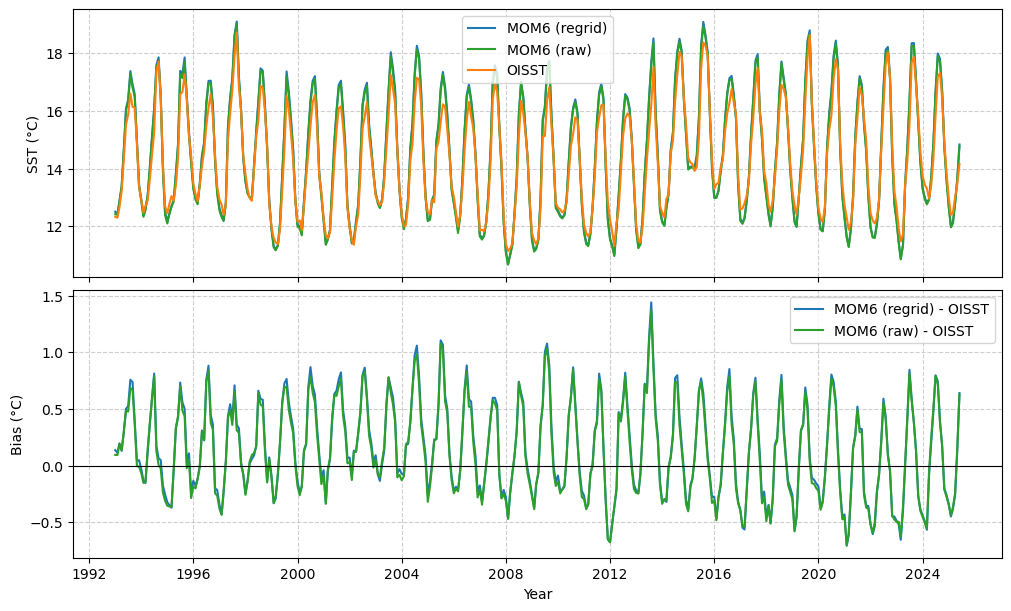

In [16]:
# visualize time series with average temperatures and bias

# create a figure with 2 rows and 1 column, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 6), layout="constrained", sharex=True
)

# subplot a) average temperatures for both MOM6 products and OISST
mom6_mean_temporal_regrid.plot(ax=ax1, label="MOM6 (regrid)", color="tab:blue")
mom6_mean_temporal_raw.plot(ax=ax1, label="MOM6 (raw)", color="tab:green")
oisst_mean_temporal.plot(ax=ax1, label="OISST", color="tab:orange")
ax1.legend()
ax1.set_ylabel("SST (°C)")
ax1.set_xlabel("")

# subplot b) bias for both MOM6 products
bias_temporal_regrid.plot(ax=ax2, label="MOM6 (regrid) - OISST", color="tab:blue")
bias_temporal_raw.plot(ax=ax2, label="MOM6 (raw) - OISST", color="tab:green")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.legend()
ax2.set_ylabel("Bias (°C)")
ax2.set_xlabel("Year")

# add grid
ax1.grid(True, linestyle="--", alpha=0.6)
ax2.grid(True, linestyle="--", alpha=0.6)

# display plot
plt.show()

In the California Current, MOM6-NEP10k captures seasonal variability in sea surface temperature (time series are well aligned), and is slightly more variable (with higher highs, and lower lows) than OISST. The comparison is consistent for MOM6 (raw) and MOM6 (regrid).

/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/shapely/creation.py:730:

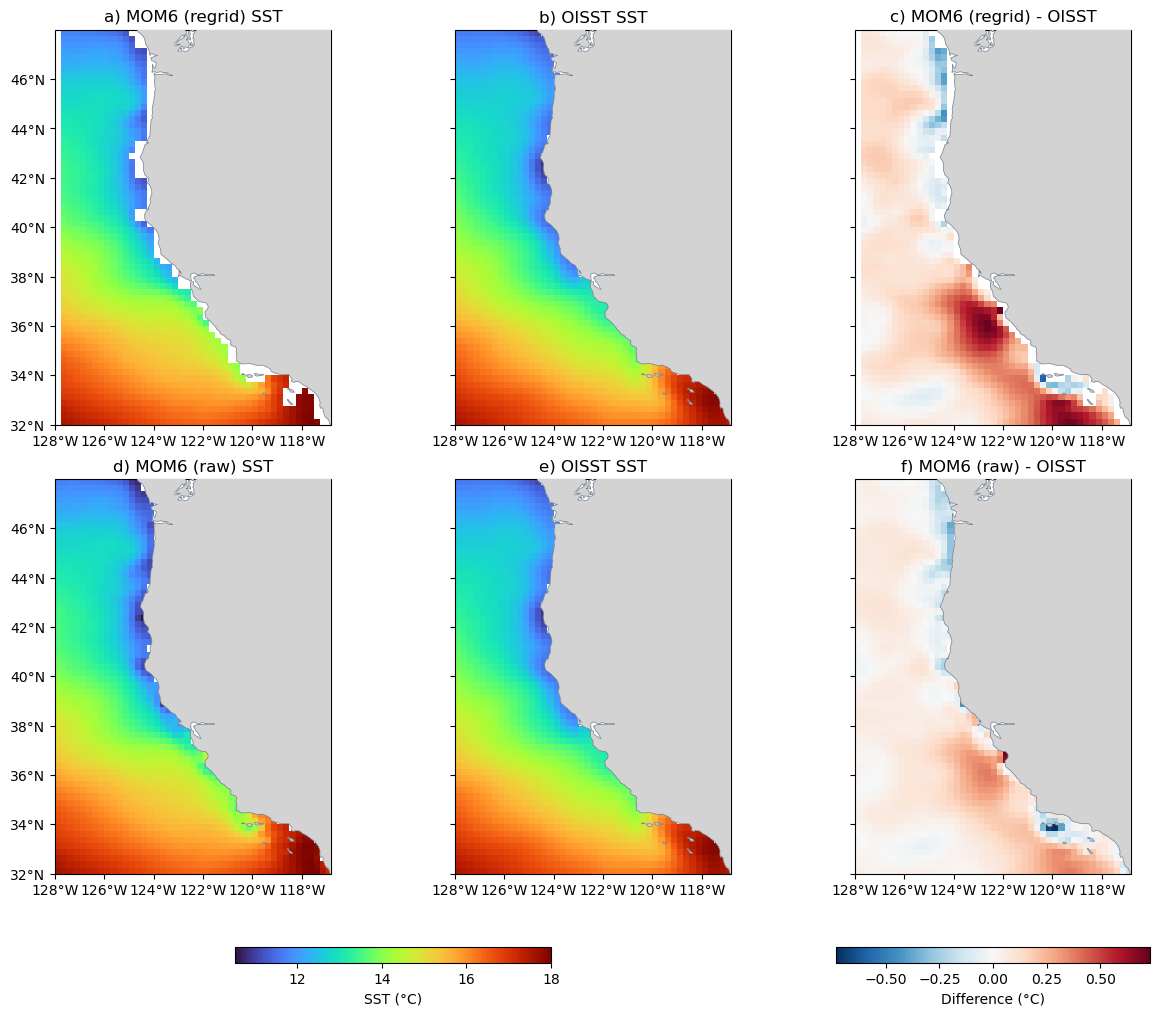

In [17]:
# visualize maps with average temperatures and bias

# create a figure with 1 row and 3 columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 10),
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()},
)
axes = axes.ravel()

# shared SST range across both MOM6 products and OISST
vmin = min(
    mom6_spatial_regrid.min().item(),
    mom6_spatial_raw.min().item(),
    oisst_spatial.min().item(),
)
vmax = max(
    mom6_spatial_regrid.max().item(),
    mom6_spatial_raw.max().item(),
    oisst_spatial.max().item(),
)

# shared and symmetric range across both bias maps
bias_limit = max(
    abs(bias_spatial_regrid.min().item()),
    abs(bias_spatial_regrid.max().item()),
    abs(bias_spatial_raw.min().item()),
    abs(bias_spatial_raw.max().item()),
)

# colormaps
cmap_sst = "turbo"  # 'jet' or 'nipy_spectral' also work for blue-to-red
cmap_bias = "RdBu_r"  # Blue to White to Red diverging colormap

# first row: MOM6 (regrid), OISST, and difference
im0 = mom6_spatial_regrid.plot(
    ax=axes[0],
    cmap=cmap_sst,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[0].set_title("a) MOM6 (regrid) SST")

im1 = oisst_spatial.plot(
    ax=axes[1],
    cmap=cmap_sst,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[1].set_title("b) OISST SST")

im2 = bias_spatial_regrid.plot(
    ax=axes[2],
    cmap=cmap_bias,
    center=0,  # lock white to 0
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[2].set_title("c) MOM6 (regrid) - OISST")

# second row: MOM6 (raw), OISST (again), and difference
im3 = mom6_spatial_raw.plot(
    ax=axes[3],
    cmap=cmap_sst,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[3].set_title("d) MOM6 (raw) SST")

im4 = oisst_spatial.plot(
    ax=axes[4],
    cmap=cmap_sst,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[4].set_title("e) OISST SST")

im5 = bias_spatial_raw.plot(
    ax=axes[5],
    cmap=cmap_bias,
    center=0,  # lock white to 0
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
axes[5].set_title("f) MOM6 (raw) - OISST")

# coastline
land1 = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="slategray", facecolor="lightgray"
)

# axis formatting
for i, ax in enumerate(axes):
    # add coastline to all subplots
    ax.add_feature(land1, linewidth=0.5, zorder=40)

    # set map extent for all subplots
    ax.set_extent(
        [
            lon_bounds[0] - 360,
            lon_bounds[1] - 360,
            lat_bounds[0],
            lat_bounds[1],
        ],
        crs=ccrs.PlateCarree(),
    )

    # remove axis labels to all subplots
    ax.set_xlabel("")
    ax.set_ylabel("")

    # set tick locations
    ax.set_xticks(
        np.arange(lon_bounds[0] - 360, lon_bounds[1] - 360, 2),
        crs=ccrs.PlateCarree(),
    )
    ax.set_yticks(
        np.arange(lat_bounds[0], lat_bounds[1], 2),
        crs=ccrs.PlateCarree(),
    )

    # add longitude labels to all subplots
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))

    if i in [0, 3]:
        # add latitude labels to first columns of subplots
        ax.yaxis.set_major_formatter(LatitudeFormatter())
    else:
        # remove y-axis label for subplots b and c
        ax.set_yticklabels([])

# shared colorbar for temperature and bias
fig.colorbar(
    im0,
    ax=[axes[0], axes[1], axes[3], axes[4]],
    location="bottom",
    label="SST (°C)",
    shrink=0.4,
)
fig.colorbar(
    im2,
    ax=[axes[2], axes[5]],
    location="bottom",
    label="Difference (°C)",
    shrink=0.8,
)

# display plot
plt.show()

In the California Current, MOM6-NEP10k captures spatial variability in sea surface temperature. Spatial patterns are similar to observational data, with cooler waters off the Pacific Northwest coast, and progressively warmer surface temperatures to the south and east. There are two areas of warmer bias around 0.5°C concentrated near Monterey Bay and south of the Channel Islands, and cooler bias around -0.3°C nearshore in Washington and surrounding the Channel Islands.

The comparison is similar for MOM6 (raw) and MOM6 (regrid), though the differences are less pronounced with raw data, even though both are regridded to match the OISST grid. The concentrated areas of warmer bias are ~0.25°C with the raw data rather than ~0.5°C with the regrid data. It is possible this is due to a difference in the regridding method when post processing the data, rather than an inherent difference between the raw and regridded data - the rectilinear MOM6 (raw) data was gridded with the xarray library (which runs faster and was conveniently already imported to manipulate netCDF data), and the curvilinear MOM6 (regrid) data with the xemsf library (because the faster xarray approach does not work for curvilinear grids, and requires installing an additional package). These approaches were based off suggestions from generative AI tools and web searches, and both approaches were quite fast and easy to implement, so it's plausible that others working with this data for the first time would take either approach. If one approach is preferable from an oceanographer's perspective, it would be useful to include that in data documentation (such as the CEFI cookbook), so others working with the data follow a consistent set of best practices and save time developing their code.

Another potential improvement for this comparison between MOM6 raw and regrid against observational data would be to regrid all three datasets to a lower resolution regular grid before comparing, rather than regridding both to match the observational data. The resolution of the rectilinear MOM6 (regrid) was lower resolution longitudinally (0.28 degrees) than the regular OISST grid (0.25 degrees). It is a small difference for this comparison, but would have bigger impacts if the difference between model and observational grid resolution was larger. This would also be useful to document for new MOM6 users who are not in the habit of thinking about these details in data processing.